### Can a computer learn if we're going to detect gravitational waves?

All experiments have selection effects. Some sources are easier to detect than others which distorts the population of sources we observe (this crucial in astronomy! Surveys are typically flux limited). 
In order to decided if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our selection effects (for instance: it would be wrong to say that all stars are close by just because we can't observe those that are very far!). In observational astronomy, this is known as [Malmquist bias](https://en.wikipedia.org/wiki/Malmquist_bias) and was first formulated in 1922.
 
**The goal here is to machine-learn the LIGO detectability: can we *predict* if a gravitational-wave source will be detected?**  

[This dataset](https://github.com/dgerosa/pdetclassifier/releases/download/v0.2/sample_2e7_design_precessing_higherordermodes_3detectors.h5) contains simulated gravitational-wave signals from merging black holes (careful the file size is >1 GB). If you've never seen them, the [.h5 format](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) is a highly optimized storage strategy for large datasets. It's amazing. In python, you can read it with `h5py`.

In particular, each source has the following features:
- `mtot`: the total mass of the binary
- `q`: the mass ratio
- `chi1x`, `chi1y`, `chi1z`, `chi2x`, `chi2y`, `chi2z`: the components of the black-hole spins in a suitable reference frame.
- `ra`, `dec`: the location of the source in the sky
- `iota`: the inclination of the orbital plane'
- `psi`: the polarization angle (gravitational waves have two polarization states much like light)
- `z`: the redshift

The detectability is defined using the `snr` (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network. Some (many?) of you will have studied this in the gravitational-wave class; [see here](https://arxiv.org/abs/1908.11170) for a nice write-up. All you need to know now is that we threshold the `snr` values and assume that LIGO will (not) see a source if `snr`>12 (`snr`<12). The resulting 0-1 labels are reported in the `det` attribute in the dataset.

Today's task is to train a classifier (you decide which one!) and separate sources that are detectables from those that aren't. 

Be creative! This is a challenge! Let's see who gets the  higher completeness and/or the smaller contamination (on a validation set, of course, careful with overfitting here).

*Tips*:
- You can downsample the data for debugging purposes
- You can also use only some of the features.
- Plot ROC curves
- **Important** Don't use `snr` as feature in your classifer (that's the answer...)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from astroML.utils import completeness_contamination
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve as ROC
from sklearn.metrics import precision_recall_curve as PRC

In [12]:
import h5py
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

print(f.keys())
print('Number of samples = ', len(f['chi1x']))

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>
Number of samples =  20000000


In [28]:
key_X = f.keys() - {'det'} - {'snr'}
X = [f[k][:100000] for k in key_X]
X = np.array(X).T
y = f['det'][:100000]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, test_size=0.25)

Let's use a Decision Tree as a classifier with different values for the maximum depth:

In [60]:
depths = np.arange(1, 16)

classifiers_DT = []
predictions_DT = []
probabilities_DT = []

for depth in depths:
    clf_DT = DecisionTreeClassifier(max_depth=depth, criterion='entropy')
    clf_DT.fit(X_train, y_train)
    classifiers_DT.append(clf_DT)
    predictions_DT.append(clf_DT.predict(X_test))
    probabilities_DT.append(clf_DT.predict_proba(X_test))
compl_DT, cont_DT = completeness_contamination(predictions_DT, y_test)

print ('Completeness: ', compl_DT)
print ('Contamination: ', cont_DT)

Completeness:  [0.8679868  0.52970297 0.85011001 0.82315732 0.67629263 0.83168317
 0.75770077 0.83278328 0.8319582  0.84048405 0.84845985 0.83250825
 0.8239824  0.82288229 0.82013201]
Contamination:  [0.32434168 0.08460076 0.27695906 0.21091484 0.10679259 0.17848411
 0.12261146 0.1360913  0.14980326 0.14993046 0.15479452 0.14660276
 0.14837976 0.16564417 0.16493979]


Text(0, 0.5, 'Score')

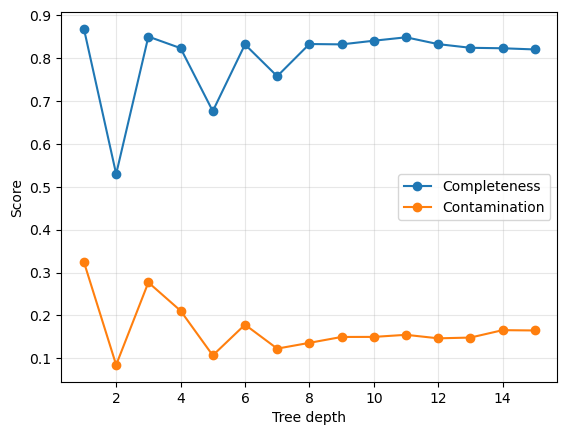

In [61]:
plt.plot(depths, compl_DT, '-o', label='Completeness')
plt.plot(depths, cont_DT, '-o', label='Contamination')
plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('Tree depth')
plt.ylabel('Score')

After depth = 8, contamination increases while completeness does not improve significantly, indicating overfitting. We therefore choose 8 as the optimal maximum depth value.

Let's now see what results we get if we use a Bagged Decision Tree:

In [76]:
clf_BDT = BaggingClassifier(DecisionTreeClassifier(max_depth=8, criterion='entropy'),
                          n_estimators=50, bootstrap=True, n_jobs=-1)
clf_BDT.fit(X_train, y_train)
y_pred_BDT = clf_BDT.predict(X_test)
y_prob_BDT = clf_BDT.predict_proba(X_test)
compl_BDT, cont_BDT = completeness_contamination(y_pred_BDT, y_test)

print('DT Completeness: ', compl_DT[7])
print('DT Contamination: ', cont_DT[7])
print ('BDT Completeness: ', compl_BDT)
print ('BDT Contamination: ', cont_BDT)

DT Completeness:  0.8327832783278328
DT Contamination:  0.1360912981455064
BDT Completeness:  0.8382838283828383
BDT Contamination:  0.11983829049956685


It seems that Bagged Decision Tree performs slighlty better than the original one. But what if i use a Random Forest?

In [77]:
clf_RF = RandomForestClassifier(n_estimators=100, max_depth=8, criterion='entropy', n_jobs=-1)
clf_RF.fit(X_train, y_train)
y_pred_RF = clf_RF.predict(X_test)
y_prob_RF = clf_RF.predict_proba(X_test)
compl_RF, cont_RF = completeness_contamination(y_pred_RF, y_test)

print ('RF Completeness: ', compl_RF)
print ('RF Contamination: ', cont_RF)

RF Completeness:  0.7931793179317932
RF Contamination:  0.10434782608695652


Let's take a look at the ROC curves for these three classifiers:

DT accuracy score: 0.9566
BDT accuracy score: 0.95988
RF accuracy score: 0.95648


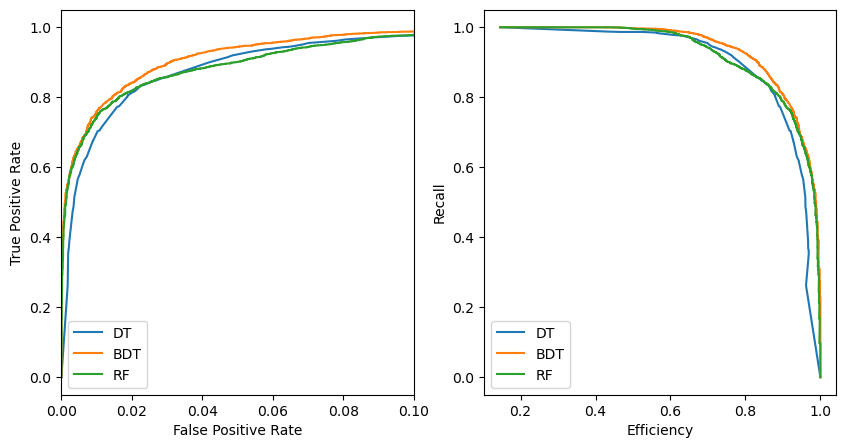

In [92]:
fpr_DT, tpr_DT, th_DT = ROC(y_test, probabilities_DT[7][:,1])
pr_DT, acc_DT, th_DT = PRC(y_test, probabilities_DT[7][:,1])

fpr_BDT, tpr_BDT, th_BDT = ROC(y_test, y_prob_BDT[:,1])
pr_BDT, acc_BDT, th_BDT = PRC(y_test, y_prob_BDT[:,1])

fpr_RF, tpr_RF, th_RF = ROC(y_test, y_prob_RF[:,1])
pr_RF, acc_RF, th_RF = PRC(y_test, y_prob_RF[:,1])

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].plot(fpr_DT, tpr_DT, label='DT')
ax[0].plot(fpr_BDT, tpr_BDT, label='BDT')
ax[0].plot(fpr_RF, tpr_RF, label='RF')
ax[0].set_xlim(0, 0.1)
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()

ax[1].plot(pr_DT, acc_DT, label='DT')
ax[1].plot(pr_BDT, acc_BDT, label='BDT')
ax[1].plot(pr_RF, acc_RF, label='RF')
ax[1].set_xlabel('Efficiency')
ax[1].set_ylabel('Recall')
ax[1].legend()

print('DT accuracy score:', accuracy_score(y_test, predictions_DT[7]))
print('BDT accuracy score:', accuracy_score(y_test, y_pred_BDT))
print('RF accuracy score:', accuracy_score(y_test, y_pred_RF))

The BDT is the best between the three!